# Complete Emotion Detection using PyTorch

This notebook covers the full end-to-end emotion detection pipeline using **PyTorch**, implementing a **Hybrid Model (DistilBERT + BiLSTM + Dense Head)**. It uses `DistilBertTokenizerFast`, handles class weights, applies early stopping & checkpointing, and is specifically built to run perfectly in Google Colab (Python 3.12 + GPU).

In [2]:
# =========================
# Cell 1: Install and Import Libraries
# =========================
!pip install torch torchvision torchaudio transformers pandas numpy scikit-learn matplotlib seaborn emoji

import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import emoji

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, classification_report
from sklearn.utils.class_weight import compute_class_weight

from transformers import DistilBertTokenizerFast, DistilBertModel

# Set device to GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 20.4 MB/s eta 0:00:00
Using device: cuda


In [5]:
# =========================
dataset_path = 'text.csv'

df = pd.read_csv(dataset_path)
df.columns



Index(['Feeling', 'input'], dtype='object')

In [6]:
df.rename(columns={
    'input': 'text',
    'Feeling': 'label'
}, inplace=True)

In [7]:
print("\n--- Dataset Head ---")
display(df.head())

print("\n--- Class Distribution ---")
print(df['label'].value_counts())

print("\n--- Missing Values ---")
print(df.isnull().sum())



--- Dataset Head ---


,label,text
0,happy,": ed ""rt : time is ticking fast. relive the pa..."
1,happy,": &はすか ed ""rt : ＃コナモンの日 だそうで、コナモンさんこと雑渡昆奈門さんのコ..."
2,happy,": ♡ ed ""happy birthday to one smokin hot mama ..."
3,happy,": [씍쯴사랑로봇] jwinnie is the best, cheer up jwinn..."
4,happy,": wth u vc♥ ed ""good morning dear❤ wishing you..."



--- Class Distribution ---
label
happy       3928
sad         2849
angry       1341
fear         863
disgust      637
surprise     399
Name: count, dtype: int64

--- Missing Values ---
label    0
text     0
dtype: int64


In [8]:
# Cell 3: Text Preprocessing
def preprocess_text(text):
    text = str(text)
    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    # Remove user mentions
    text = re.sub(r'@\w+', '', text)
    # Remove hashtags
    text = re.sub(r'#\w+', '', text)

    # Convert emojis to text representation to preserve meaning (e.g. 😊 -> :smiling_face_with_smiling_eyes:)
    text = emoji.demojize(text)
    # Lowercase text
    text = text.lower()
    return text.strip()

df['cleaned_text'] = df['text'].apply(preprocess_text)
df.dropna(subset=['cleaned_text', 'label'], inplace=True)

# Encode labels globally
label_encoder = LabelEncoder()
df['label_id'] = label_encoder.fit_transform(df['label'])

print("Label Mapping:")
for i, label in enumerate(label_encoder.classes_):
    print(f"{i}: {label}")


Label Mapping:
0: angry
1: disgust
2: fear
3: happy
4: sad
5: surprise


In [9]:

# Cell 4: Train-Test Split & Class Weights
X = df['cleaned_text'].values
y = df['label_id'].values

# 80/20 train/test split
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Further split training into train and validation (90/10 of the training data)
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.1, random_state=42, stratify=y_train_full)

# Compute class weights to handle dataset imbalance
unique_classes = np.unique(y_train)
weights_arr = compute_class_weight('balanced', classes=unique_classes, y=y_train)

# Convert to PyTorch Tensor so it can be passed to our loss function later
class_weights_tensor = torch.tensor(weights_arr, dtype=torch.float32).to(device)
print("\nClass Weights applied:", weights_arr)

print(f"\nTraining set shape: X={X_train.shape}, y={y_train.shape}")
print(f"Validation set shape: X={X_val.shape}, y={y_val.shape}")
print(f"Test set shape: X={X_test.shape}, y={y_test.shape}")



Class Weights applied: [1.24413389 2.61837328 1.93531938 0.42512675 0.58597432 4.18757259]

Training set shape: X=(7211,), y=(7211,)
Validation set shape: X=(802,), y=(802,)
Test set shape: X=(2004,), y=(2004,)


In [10]:
# : Tokenization & PyTorch DataLoaders
MODEL_NAME = 'distilbert-base-uncased'
tokenizer = DistilBertTokenizerFast.from_pretrained(MODEL_NAME)
MAX_LENGTH = 128
BATCH_SIZE = 16

class EmotionDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]

        encoding = self.tokenizer(
            text,
            add_special_tokens=True,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

train_dataset = EmotionDataset(X_train, y_train, tokenizer, MAX_LENGTH)
val_dataset = EmotionDataset(X_val, y_val, tokenizer, MAX_LENGTH)
test_dataset = EmotionDataset(X_test, y_test, tokenizer, MAX_LENGTH)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [11]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))

Using device: cuda
CUDA available: True
GPU name: Tesla T4


In [12]:
#  Build PyTorch Hybrid Model (DistilBERT + BiLSTM)
#
class HybridEmotionModel(nn.Module):
    def __init__(self, num_labels, model_name=MODEL_NAME, hidden_dim=64, dropout_rate=0.3):
        super(HybridEmotionModel, self).__init__()

        # Load Base DistilBERT Model (not for sequence classification, just the base hidden states)
        self.distilbert = DistilBertModel.from_pretrained(model_name)

        # BiLSTM Layer taking DistilBERT's hidden states as input
        self.bilstm = nn.LSTM(
            input_size=self.distilbert.config.hidden_size,
            hidden_size=hidden_dim,
            num_layers=1,
            batch_first=True,
            bidirectional=True
        )

        self.dropout = nn.Dropout(dropout_rate)

        # Dense Head for Output Classification
        self.classifier = nn.Linear(hidden_dim * 2, num_labels)

    def forward(self, input_ids, attention_mask):
        # Pass through DistilBERT
        outputs = self.distilbert(input_ids=input_ids, attention_mask=attention_mask)
        sequence_output = outputs.last_hidden_state  # shape: [batch_size, seq_len, hidden_size]

        # Pass through BiLSTM
        lstm_output, (h_n, c_n) = self.bilstm(sequence_output)

        # h_n shape: [2 (num_directions), batch_size, hidden_dim]
        # Concatenate the final forward and backward hidden states
        hidden = torch.cat((h_n[-2, :, :], h_n[-1, :, :]), dim=1)

        # Dropout & Classifier
        x = self.dropout(hidden)
        logits = self.classifier(x)

        return logits

num_classes = len(label_encoder.classes_)
hybrid_model = HybridEmotionModel(num_labels=num_classes).to(device)
print(hybrid_model)


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


HybridEmotionModel(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)
            (lin1

In [13]:
# Callbacks (EarlyStopping & ModelCheckpoint)
class EarlyStopping:
    """Early stops the training if validation loss doesn't improve after a given patience."""
    def __init__(self, patience=3, verbose=True, path='best_hybrid_pytorch.pth'):
        self.patience = patience
        self.verbose = verbose
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.val_loss_min = np.inf
        self.path = path

    def __call__(self, val_loss, model):
        score = -val_loss
        if self.best_score is None:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
        elif score < self.best_score:
            self.counter += 1
            if self.verbose:
                print(f'EarlyStopping counter: {self.counter} out of {self.patience}')
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
            self.counter = 0

    def save_checkpoint(self, val_loss, model):
        """Saves model when validation loss decrease."""
        if self.verbose:
            print(f'Validation loss decreased ({self.val_loss_min:.6f} --> {val_loss:.6f}). Saving model...')
        torch.save(model.state_dict(), self.path)
        self.val_loss_min = val_loss


In [14]:
# : Training & Evaluation Loop
EPOCHS = 10
LEARNING_RATE = 5e-5

optimizer = torch.optim.AdamW(hybrid_model.parameters(), lr=LEARNING_RATE)
# Loss function properly configured with dataset class weights!
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

# ReduceLROnPlateau equivalent
# ReduceLROnPlateau
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=2
)

# Early Stopping
early_stopping = EarlyStopping(patience=3, verbose=True, path='best_hybrid_pytorch.pth')

history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

print("\n--- Starting Training ---")
for epoch in range(EPOCHS):
    # --- Training Phase ---
    hybrid_model.train()
    total_train_loss, total_train_correct, train_samples = 0, 0, 0

    for batch in train_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        optimizer.zero_grad()
        logits = hybrid_model(input_ids, attention_mask)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()
        preds = torch.argmax(logits, dim=1)
        total_train_correct += (preds == labels).sum().item()
        train_samples += labels.size(0)

    avg_train_loss = total_train_loss / len(train_loader)
    train_acc = total_train_correct / train_samples

    # --- Validation Phase ---
    hybrid_model.eval()
    total_val_loss, total_val_correct, val_samples = 0, 0, 0

    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            logits = hybrid_model(input_ids, attention_mask)
            loss = criterion(logits, labels)

            total_val_loss += loss.item()
            preds = torch.argmax(logits, dim=1)
            total_val_correct += (preds == labels).sum().item()
            val_samples += labels.size(0)

    avg_val_loss = total_val_loss / len(val_loader)
    val_acc = total_val_correct / val_samples

    history['train_loss'].append(avg_train_loss)
    history['val_loss'].append(avg_val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    print(f"Epoch [{epoch+1}/{EPOCHS}] - Train Loss: {avg_train_loss:.4f}, Train Acc: {train_acc:.4f}  |  Val Loss: {avg_val_loss:.4f}, Val Acc: {val_acc:.4f}")

    # LR Scheduler Step
    scheduler.step(avg_val_loss)

    # Early Stopping Check
    early_stopping(avg_val_loss, hybrid_model)
    if early_stopping.early_stop:
        print("Early stopping triggered! Training halted.")
        break

# Load best model weights
hybrid_model.load_state_dict(torch.load('best_hybrid_pytorch.pth'))
print("Training Complete! Loaded best model weights.")



--- Starting Training ---
Epoch [1/10] - Train Loss: 0.9105, Train Acc: 0.6916  |  Val Loss: 0.4197, Val Acc: 0.8815
Validation loss decreased (inf --> 0.419676). Saving model...
Epoch [2/10] - Train Loss: 0.3743, Train Acc: 0.8835  |  Val Loss: 0.3822, Val Acc: 0.8828
Validation loss decreased (0.419676 --> 0.382207). Saving model...
Epoch [3/10] - Train Loss: 0.2650, Train Acc: 0.9171  |  Val Loss: 0.3767, Val Acc: 0.8890
Validation loss decreased (0.382207 --> 0.376722). Saving model...
Epoch [4/10] - Train Loss: 0.2031, Train Acc: 0.9309  |  Val Loss: 0.3551, Val Acc: 0.8978
Validation loss decreased (0.376722 --> 0.355086). Saving model...
Epoch [5/10] - Train Loss: 0.1610, Train Acc: 0.9505  |  Val Loss: 0.4865, Val Acc: 0.9002
EarlyStopping counter: 1 out of 3
Epoch [6/10] - Train Loss: 0.1333, Train Acc: 0.9570  |  Val Loss: 0.3622, Val Acc: 0.9102
EarlyStopping counter: 2 out of 3
Epoch [7/10] - Train Loss: 0.0952, Train Acc: 0.9732  |  Val Loss: 0.4678, Val Acc: 0.9127
Early


--- Evaluating on Test Data ---
Test Accuracy:  0.8882
Test Precision: 0.8965
Test Recall:    0.8882
Test F1-score:  0.8903

Classification Report:
              precision    recall  f1-score   support

       angry       0.90      0.94      0.92       268
     disgust       0.92      0.96      0.94       127
        fear       0.82      0.84      0.83       173
       happy       0.92      0.89      0.90       786
         sad       0.93      0.85      0.89       570
    surprise       0.57      0.89      0.70        80

    accuracy                           0.89      2004
   macro avg       0.84      0.90      0.86      2004
weighted avg       0.90      0.89      0.89      2004



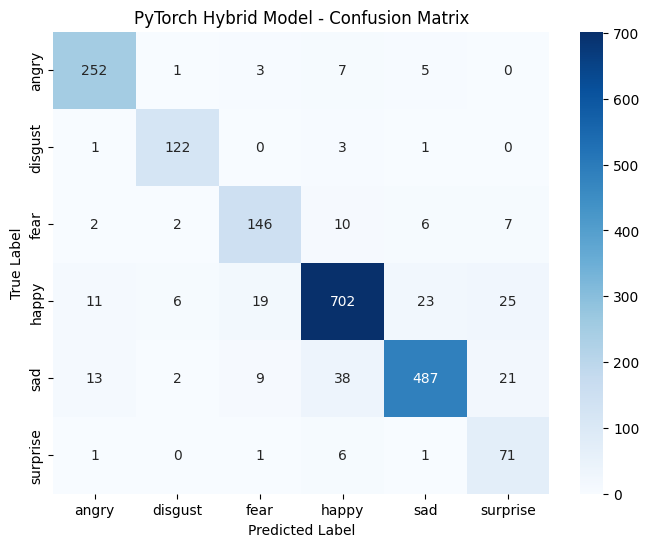

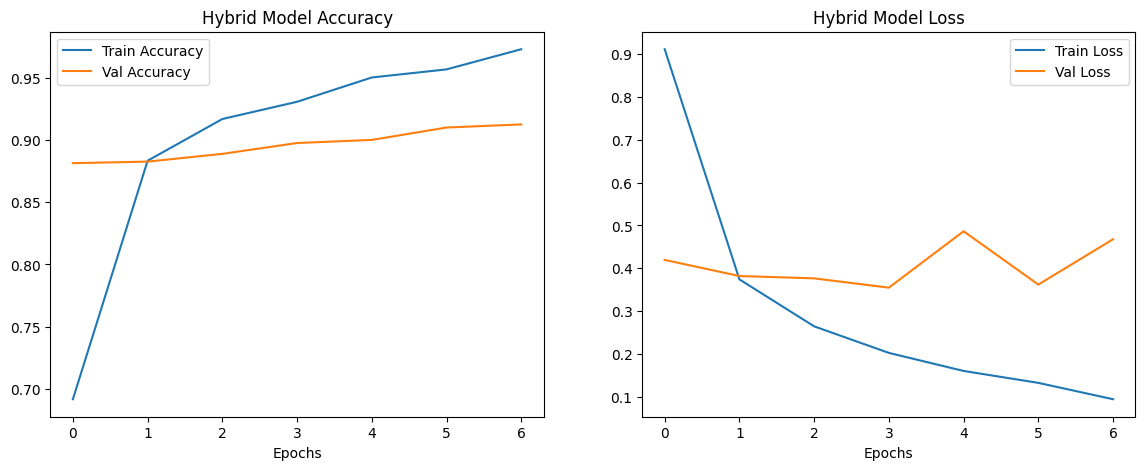

In [15]:
#  Evaluate PyTorch Model
hybrid_model.eval()
all_preds = []
all_labels = []

print("\n--- Evaluating on Test Data ---")
with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        logits = hybrid_model(input_ids, attention_mask)
        preds = torch.argmax(logits, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Calculate metrics
acc = accuracy_score(all_labels, all_preds)
precision, recall, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average='weighted', zero_division=0)

print(f"Test Accuracy:  {acc:.4f}")
print(f"Test Precision: {precision:.4f}")
print(f"Test Recall:    {recall:.4f}")
print(f"Test F1-score:  {f1:.4f}")

print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=label_encoder.classes_))

# Plot Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title("PyTorch Hybrid Model - Confusion Matrix")
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# Plot Training Curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(history['train_acc'], label='Train Accuracy')
ax1.plot(history['val_acc'], label='Val Accuracy')
ax1.set_title('Hybrid Model Accuracy')
ax1.set_xlabel('Epochs')
ax1.legend()

ax2.plot(history['train_loss'], label='Train Loss')
ax2.plot(history['val_loss'], label='Val Loss')
ax2.set_title('Hybrid Model Loss')
ax2.set_xlabel('Epochs')
ax2.legend()
plt.show()


In [16]:
#  Prediction Function
def predict_emotion(text):
    print(f"\n{'='*40}\nPREDICTING EMOTION FOR: '{text}'")
    hybrid_model.eval()

    # 1. Clean
    clean_text = preprocess_text(text)

    # 2. Tokenize (PyTorch Tensor format)
    encoding = tokenizer(
        clean_text,
        add_special_tokens=True,
        max_length=MAX_LENGTH,
        padding='max_length',
        truncation=True,
        return_tensors='pt'
    )

    input_ids = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)

    # 3. Predict
    with torch.no_grad():
        logits = hybrid_model(input_ids, attention_mask)
        probs = torch.softmax(logits, dim=1).cpu().numpy()[0]

    pred_class_id = np.argmax(probs)
    confidence = probs[pred_class_id]

    predicted_label = label_encoder.inverse_transform([pred_class_id])[0]

    print(f"Probabilities:\n{dict(zip(label_encoder.classes_, np.round(probs, 3)))}")
    print(f"\nFINAL PREDICTION: {predicted_label.upper()} (Confidence: {confidence:.2%})")
    print(f"{'='*40}")

    return predicted_label, confidence

# Test predictions
predict_emotion("I am very happy today 😊")
predict_emotion("This is completely unacceptable and makes me so angry 😡")



PREDICTING EMOTION FOR: 'I am very happy today 😊'
Probabilities:
{'angry': np.float32(0.004), 'disgust': np.float32(0.003), 'fear': np.float32(0.008), 'happy': np.float32(0.975), 'sad': np.float32(0.006), 'surprise': np.float32(0.005)}

FINAL PREDICTION: HAPPY (Confidence: 97.52%)

PREDICTING EMOTION FOR: 'This is completely unacceptable and makes me so angry 😡'
Probabilities:
{'angry': np.float32(0.973), 'disgust': np.float32(0.006), 'fear': np.float32(0.006), 'happy': np.float32(0.005), 'sad': np.float32(0.008), 'surprise': np.float32(0.003)}

FINAL PREDICTION: ANGRY (Confidence: 97.26%)


('angry', np.float32(0.97255075))